In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
from torch import nn
from torch.optim import SGD
from torch.nn.functional import one_hot
import matplotlib.pyplot as plt
import torch
from tqdm.notebook import tqdm
from  IPython.display import clear_output

In [ ]:
ds = datasets.FashionMNIST('.', download=True, train=True, transform=ToTensor())

In [ ]:
len(ds.classes)


10

In [ ]:
loader = DataLoader(ds, 32, True)

In [ ]:
CNN = nn.Sequential(nn.BatchNorm2d(1),
                    nn.Conv2d(1, 10, 3, padding=1), # 28x28x1 -> 28x28x10
                    nn.LeakyReLU(),
                    nn.BatchNorm2d(10),
                    nn.MaxPool2d(2), # 28x28x10 -> 14x14x10
                    nn.Conv2d(10, 20, 3, padding=1), # 14x14x10 -> 14x14x20
                    nn.LeakyReLU(),
                    nn.BatchNorm2d(20),
                    nn.MaxPool2d(2), # 14x14x20 -> 7x7x20
                    nn.Conv2d(20, 40, 3, padding=1), # 7x7x20 -> 7x7x40
                    nn.LeakyReLU(),
                    nn.BatchNorm2d(40),
                    nn.MaxPool2d(2), # 7x7x40 -> 3x3x40

                    nn.Flatten(),
                    nn.BatchNorm1d(360),
                    nn.Linear(360, 64),
                    nn.LeakyReLU(),
                    nn.BatchNorm1d(64),
                    nn.Linear(64, 10)).cuda()

In [ ]:
opt = SGD(CNN.parameters(), lr=8e-3)

In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
nIter = 7

losses = []
accuracies = []
CNN.train(True)
for i in tqdm(range(nIter)):
    batchLosses = []
    batchAccuracies = []
    for x, y in tqdm(loader):
        x = x.cuda()
        y = y.cuda()
        pred = CNN(x)
        err = criterion(pred, y)
        err.backward()
        opt.step()
        opt.zero_grad()
        loss = err.item()
        accuracy = torch.mean((torch.argmax(pred, dim=1) == y).float()).cpu()
        batchLosses.append(loss)
        batchAccuracies.append(accuracy)
    meanLoss = sum(batchLosses) / len(batchLosses)
    meanAccuracy = sum(batchAccuracies) / len(batchAccuracies)
    losses.append(meanLoss)
    accuracies.append(meanAccuracy)
    print(f'meanLoss - {meanLoss}')
    print(f'meanAccuracy - {meanAccuracy}')
plt.figure()
plt.title('Losses')
plt.plot(losses)
plt.figure()
plt.title('Accuracies')
plt.plot(accuracies)

NameError: ignored

In [ ]:
dsTest = datasets.FashionMNIST('.', download=True, transform=ToTensor())

  0%|          | 0/26421880 [00:00<?, ?it/s]

Extracting ./FashionMNIST/raw/train-images-idx3-ubyte.gz to ./FashionMNIST/raw



  0%|          | 0/29515 [00:00<?, ?it/s]

Extracting ./FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./FashionMNIST/raw



  0%|          | 0/4422102 [00:00<?, ?it/s]

Extracting ./FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./FashionMNIST/raw



  0%|          | 0/5148 [00:00<?, ?it/s]

Extracting ./FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./FashionMNIST/raw



In [ ]:
testLoader = DataLoader(dsTest, 32, True)
for i, j in testLoader:
    print(i.shape)

torch.Size([60000, 28, 28])

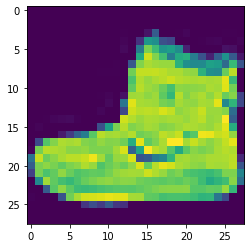

In [ ]:
plt.imshow(dsTest.data[0])
dsTest.data.shape

In [ ]:
dsTest.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
dsTest.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [ ]:
acc = []
CNN.train(False)
for x, y in tqdm(testLoader):
    x = x.cuda()
    y = y.cuda()
    pred = CNN(x)
    accuracy = torch.mean((torch.argmax(pred, dim=1) == y).float()).cpu()
    acc.append(accuracy)
sum(acc) / len(acc)

  0%|          | 0/1875 [00:00<?, ?it/s]

tensor(0.9341)